# Plot [Fig. 2](Nratio, Quenched Fraction, difference of Quenched Fraction: ASGQ signal)_R/R200c
## Runtime: 180s

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import statistics
from scipy.integrate import dblquad
import os
import shutil
from SFGVQ import SFGVQ
import pickle

In [2]:
def Calculate_Ratio_And_Check(sgaldata, cgal_data, ratio_min):
    """Calculate the target ratio, verify whether any satellite galaxy lies within

    2 * r_half of its central galaxy, and return the minimum valid ratio.

    Parameters:
    -----------
    sgaldata : numpy.ndarray
        Array containing satellite galaxy catalog data
        Columns used: index 3 (radius) and index 9 (central galaxy (in same host halo) ID).
    cgal_data : numpy.ndarray
        Array containing central galaxy catalog data
        Columns used: index 8 (galaxy ID) and index 18 (half-mass radius, r_half).
    ratio_min : float
        Minimum allowable spatial ratio threshold (e.g., 2.0).

    Returns:
    --------
    float
        The minimum valid calculated ratio across all matching pairs.

    Raises:
    -------
    ValueError
        If a calculated ratio is below `ratio_min`, if a denominator is zero,
        or if no matching central galaxy is found.
    """
    # List to store all valid ratios
    all_ratios = []

    # Iterate over each satellite galaxy in sgaldata
    for i in range(sgaldata.shape[0]):
        # 1. Extract key quantities for current row
        numerator = sgaldata[i, 3]  # Satellite radial distance: sgaldata[i, 3]
        match_value = sgaldata[
            i, 9
        ]  # Matching ID condition: cgal_data[:, 8] must match this ID

        # 2. Find row indices k in cgal_data satisfying the matching condition
        match_indices = np.where(cgal_data[:, 8] == match_value)[0]

        # Check for non-matching instances
        if len(match_indices) == 0:
            raise ValueError(
                f"sgaldata row {i}: No central galaxy found in cgal_data with ID cgal_data[:, 8] = {match_value}."
            )

        # 3. Iterate over all matched central rows, calculate ratios, and check threshold
        for k in match_indices:
            denominator = cgal_data[k, 18]  # Denominator: cgal_data[k, 18]

            # Prevent division by zero
            if denominator == 0:
                raise ValueError(
                    f"sgaldata row {i} matched to cgal_data row {k}: Denominator cgal_data[{k}, 18] = 0, division by zero."
                )

            # Compute ratio
            ratio = numerator / denominator
            all_ratios.append(ratio)

            # Check if ratio is less than ratio_min threshold
            if ratio < ratio_min:
                raise ValueError(
                    f"Calculated ratio is below ratio_min ({ratio_min})! Position details:\n"
                    f"sgaldata row {i}: sgaldata[{i}, 3] = {numerator}\n"
                    f"cgal_data row {k}: cgal_data[{k}, 8] = {match_value} (match ID), cgal_data[{k}, 18] = {denominator}\n"
                    f"Computed ratio: {numerator} / {denominator} = {ratio:.4f} < {ratio_min}"
                )

    # 4. Ensure non-empty list and return minimum value
    if len(all_ratios) == 0:
        raise ValueError(
            "No valid ratios calculated. Please verify input data."
        )

    min_ratio = np.min(all_ratios)
    print(f"Minimum valid ratio across all matched galaxies: {min_ratio:.4f}")
    return min_ratio


def Plot_Process(data):
    """Process sub-sample array lists to compute ensemble averages, medians,

    standard deviations, and percentile confidence intervals (68.3% and 99.7%).

    Parameters:
    -----------
    data : list
        Nested list structure containing overall sample (index 0) and sub-samples (indices 1+).

    Returns:
    --------
    tuple
        (data_ave, data_mean, data_sigma, data_683, data_997) containing full sample
        averages, sub-sample median trends, standard deviations, 1-sigma, and 3-sigma percentile bounds.
    """
    data_ave = [[[], []], [[], []]]
    data_mean = [[[], []], [[], []]]
    data_sigma = [[[], []], [[], []]]
    data_683 = [[[], []], [[], []]]
    data_997 = [[[], []], [[], []]]

    for i in range(len(data)):
        for j in range(len(data[i])):
            if len(data[i][j]) > 0:
                # Full catalog average sample result (index 0)
                data_ave[i][j] = data[i][j][0]

                # Sub-samples for statistical error estimation (indices 1 to N)
                data_part = np.array(data[i][j][1:])
                data_mean[i][j] = np.median(data_part, axis=0)
                data_sigma[i][j] = np.std(data_part, axis=0)

                # Compute 68.3% (1-sigma) confidence interval: 15.85th and 84.15th percentiles along columns
                q1_683 = np.percentile(data_part, 15.85, axis=0).tolist()
                q2_683 = np.percentile(data_part, 84.15, axis=0).tolist()
                data_683[i][j] = [q1_683, q2_683]

                # Compute 99.7% (3-sigma) confidence interval: 0.15th and 99.85th percentiles along columns
                q1_997 = np.percentile(data_part, 0.15, axis=0).tolist()
                q2_997 = np.percentile(data_part, 99.85, axis=0).tolist()
                data_997[i][j] = [q1_997, q2_997]

    return data_ave, data_mean, data_sigma, data_683, data_997

In [3]:
# ===================== 1. Simulation Configurations =====================
simulations_config = [
    {
        "name": "SIMBA",
        "snapnum_center": "151",
        "data_base_dir": "/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm100n1024/data/",
        "starmass_min": 10**(9.5),
        "redshift": 0.0
    },
    {
        "name": "TNG100",
        "snapnum_center": "099",  # Assuming z=0 snapshot is 099 for TNG100
        "data_base_dir": "/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/TNG100/data/",
        "starmass_min": 10**(9.5),
        "redshift": 0.0
    },
    {
        "name": "EAGLE",
        "snapnum_center": "028_z000p000",  # Assuming z=0 snapshot is 028 for EAGLE
        "data_base_dir": "/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/EAGLE/data/",
        "starmass_min": 10**(9.5),
        "redshift": 0.0
    },
    {
        "name": "SIMBAnofb",
        "snapnum_center": "151",
        "data_base_dir": "/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm50n512/nofb/data/",
        "starmass_min": 10**(9.5),
        "redshift": 0.0
    },
]

# General parameters
part_type_list = ['star_axis']
axis_align_list = ['all']
RR200cRatio_bins_list = [np.array([0, 1, 3, 5, 7, 9])]

N_load = 50
sample_angle = 45  # [deg]

# Outer loop across different cosmological hydrodynamic simulations
for sim_cfg in simulations_config:
    sim_name = sim_cfg['name']
    snapnum = sim_cfg['snapnum_center']
    data_base_dir = sim_cfg['data_base_dir']
    redshift = sim_cfg['redshift']
    starmass_min = sim_cfg['starmass_min']

    print(f"\n================ Running for Simulation: {sim_name} ================")

    for axis_align_index, axis_align in enumerate(axis_align_list):
        for part_type_index, part_type in enumerate(part_type_list):

            # Base output directories for results
            dir_path0 = f'fig_data_R/{sim_name}/{part_type}'
            if not os.path.exists(dir_path0):
                os.makedirs(dir_path0, exist_ok=True)

            print(f'\nSnapnum: {snapnum} | Alignment: {axis_align} | Type: {part_type}')
            print('---------------------------------------------------------')

            # N_i == 0 represents galaxy_ave，N_i > 0 correlates to galaxy_(N_i-1) (galaxy_0 to galaxy_50)
            for N_i in range(N_load + 1):
                if N_i == 0:
                    suffix = 'ave'
                else:
                    suffix = f'{N_i - 1}'

                # Buffer path for temporary processing
                dir_path = f'buffer/{sim_name}/{part_type}/{snapnum}/{axis_align}/{suffix}'
                if os.path.exists(dir_path):
                    shutil.rmtree(dir_path)
                os.makedirs(dir_path, exist_ok=True)

                # Load simulation galaxy catalog
                galaxy_file = f'{data_base_dir}/GalInHalo_{part_type}/{snapnum}/galaxy_{suffix}.npy'
                Full_snap = np.load(galaxy_file)

                # Extract central galaxies (M200c >= 10^12 M_sun)
                mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
                cgal_data = Full_snap[mask_cgal, :]
                mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
                cgal_M_data = cgal_data[mask_cgal_M200c, :]

                # Load cluster data
                align_file = f'cluster_data/{sim_name}/{snapnum}/{axis_align}_data.pkl'
                with open(align_file, 'rb') as f:
                    axis_align_data = pickle.load(f)

                cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])
                mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
                cgal_M_data = cgal_M_data[mask_axis_state]

                # Extract satellite galaxies with stellar mass threshold
                mask_sgal = (np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & 
                             (Full_snap[:, 8] != Full_snap[:, 9]) & 
                             (Full_snap[:, 7] >= starmass_min))
                sgaldata = Full_snap[mask_sgal, :]

                # Calculate spatial distribution ratios
                RcgalR200cRatio = 2 * cgal_M_data[:, 18] / cgal_M_data[:, 17]
                RR200cRatio_bins = RR200cRatio_bins_list[axis_align_index]

                sgaldata_R = [[] for _ in range(len(RR200cRatio_bins) - 1)]
                RR200cRatio_sum = np.zeros(len(sgaldata_R))

                for i in range(len(sgaldata)):
                    for j in range(len(sgaldata_R)):
                        if (RR200cRatio_bins[j] * sgaldata[i, 17] < sgaldata[i, 3] <= RR200cRatio_bins[j + 1] * sgaldata[i, 17]):
                            sgaldata_R[j].append(sgaldata[i, :])
                            RR200cRatio_sum[j] += (sgaldata[i, 3] / sgaldata[i, 17])

                # Only print statistics when dealing with ave sample (N_i == 0)
                if N_i == 0:
                    min_ratio = Calculate_Ratio_And_Check(sgaldata, cgal_data, ratio_min=2)
                    print('Full Catalog Shape:', Full_snap.shape)
                    print('Ncgal:', len(cgal_M_data))
                    print('Ncgal_have_satellite:', len(set(sublist[9] for sublist in sgaldata)))
                    print('Nsgal:', len(sgaldata))

                    RR200cRatio_mean = np.zeros(len(sgaldata_R))
                    for i in range(len(RR200cRatio_sum)):
                        if len(sgaldata_R[i]) > 0:
                            RR200cRatio_mean[i] = RR200cRatio_sum[i] / len(sgaldata_R[i])

                    # Save ave data's mean radial bin distances for this setup
                    save_dir_mean = f'fig_data_R/{sim_name}/{part_type}/{snapnum}/{axis_align}'
                    os.makedirs(save_dir_mean, exist_ok=True)
                    np.save(f'{save_dir_mean}/RR200cRatio_mean.npy', RR200cRatio_mean)

                # Classification of Star-forming, Green Valley, and Quenched satellites
                SFgal_data = [[] for _ in range(len(sgaldata_R))]
                GVgal_data = [[] for _ in range(len(sgaldata_R))]
                Qgal_data = [[] for _ in range(len(sgaldata_R))]

                for i in range(len(sgaldata_R)):
                    base_save_path = f'buffer/{sim_name}/{part_type}/{snapnum}/{axis_align}/{suffix}'
                    SFGVQ(sample_angle, sgaldata_R[i], SFgal_data[i], GVgal_data[i], Qgal_data[i], 
                          snap_num=snapnum, redshift=redshift, bins_num=f'{i}',
                          snapnum_center=snapnum, base_save_path=base_save_path)

                # Compute directional quenched fractions
                Qfrac_major, Qfrac_minor = [], []
                N_ratio, QN_ratio, notQN_ratio, delta_Qfrac = [], [], [], []
                QF_R = []

                for i in range(len(sgaldata_R)):
                    Ndata_i = np.zeros((6, 13))
                    nqfrac_path = f'buffer/{sim_name}/{part_type}/{snapnum}/{axis_align}/{suffix}/NQfrac_{i}_{snapnum}.npy'
                    # (Ndata, QNdata, GVNdata, SFNdata, Qfracdata, orientation_index: 0/6-major, 3/9-minor)
                    Ndata_i_snapnum = np.load(nqfrac_path)

                    for j in range(Ndata_i.shape[0]):
                        for k in range(Ndata_i.shape[1]):
                            if j < 4:
                                Ndata_i[j, k] += Ndata_i_snapnum[j, k]
                            elif j == 5:
                                Ndata_i[j, k] = Ndata_i_snapnum[j, k]

                    N_anglebins = int(Ndata_i.shape[1] - 1)
                    angle_index = 0

                    # Angular binning indices for Major and Minor axes
                    idx_maj1, idx_maj2 = angle_index, angle_index + N_anglebins // 2
                    idx_min1, idx_min2 = angle_index + N_anglebins // 4, angle_index + N_anglebins * 3 // 4

                    n_maj = Ndata_i[0, idx_maj1] + Ndata_i[0, idx_maj2]
                    n_min = Ndata_i[0, idx_min1] + Ndata_i[0, idx_min2]
                    qn_maj = Ndata_i[1, idx_maj1] + Ndata_i[1, idx_maj2]
                    qn_min = Ndata_i[1, idx_min1] + Ndata_i[1, idx_min2]

                    qf_maj = qn_maj / n_maj if n_maj > 0 else np.nan
                    qf_min = qn_min / n_min if n_min > 0 else np.nan

                    QF_R.append([qf_maj, qf_min])
                    Qfrac_major.append(qf_maj)
                    Qfrac_minor.append(qf_min)

                    N_ratio.append(n_maj / n_min if n_min > 0 else np.nan)
                    QN_ratio.append(qn_maj / qn_min if qn_min > 0 else np.nan)

                    not_qn_maj = n_maj - qn_maj
                    not_qn_min = n_min - qn_min
                    notQN_ratio.append(not_qn_maj / not_qn_min if not_qn_min > 0 else np.nan)
                    delta_Qfrac.append(qf_maj - qf_min)

                    # Only print statistics when dealing with ave sample (N_i == 0)
                    if N_i == 0:
                        print(f'Bin {i} - Nmajor:', n_maj, 'Nminor:', n_min)
                        print(f'Bin {i} - QNmajor:', qn_maj, 'QNminor:', qn_min)
                        print(f'Bin {i} - QFacmajor:', qf_maj, 'QFacminor:', qf_min)
                        print('-----------------------------------------------')

                # Output data directory
                out_dir = f'fig_data_R/{sim_name}/{part_type}/{snapnum}/{axis_align}/{suffix}'
                os.makedirs(out_dir, exist_ok=True)

                np.save(f'{out_dir}/N_ratio.npy', N_ratio)
                np.save(f'{out_dir}/QN_ratio.npy', QN_ratio)
                np.save(f'{out_dir}/notQN_ratio.npy', notQN_ratio)
                np.save(f'{out_dir}/Qfrac_major.npy', Qfrac_major)
                np.save(f'{out_dir}/Qfrac_minor.npy', Qfrac_minor)


================ Running for Simulation: SIMBA ================

Snapnum: 151 | Alignment: all | Type: star_axis
---------------------------------------------------------
Minimum valid ratio across all matched galaxies: 2.4324
Full Catalog Shape: (75806, 36)
Ncgal: 3728
Ncgal_have_satellite: 3283
Nsgal: 30712
Bin 0 - Nmajor: 1200.0 Nminor: 769.0
Bin 0 - QNmajor: 891.0 QNminor: 503.0
Bin 0 - QFacmajor: 0.7425 QFacminor: 0.6540962288686606
-----------------------------------------------
Bin 1 - Nmajor: 1319.0 Nminor: 939.0
Bin 1 - QNmajor: 760.0 QNminor: 510.0
Bin 1 - QFacmajor: 0.576194086429113 QFacminor: 0.5431309904153354
-----------------------------------------------
Bin 2 - Nmajor: 1369.0 Nminor: 887.0
Bin 2 - QNmajor: 569.0 QNminor: 362.0
Bin 2 - QFacmajor: 0.4156318480642805 QFacminor: 0.4081172491544532
-----------------------------------------------
Bin 3 - Nmajor: 2039.0 Nminor: 1570.0
Bin 3 - QNmajor: 960.0 QNminor: 695.0
Bin 3 - QFacmajor: 0.47081902893575284 QFacminor: 0.

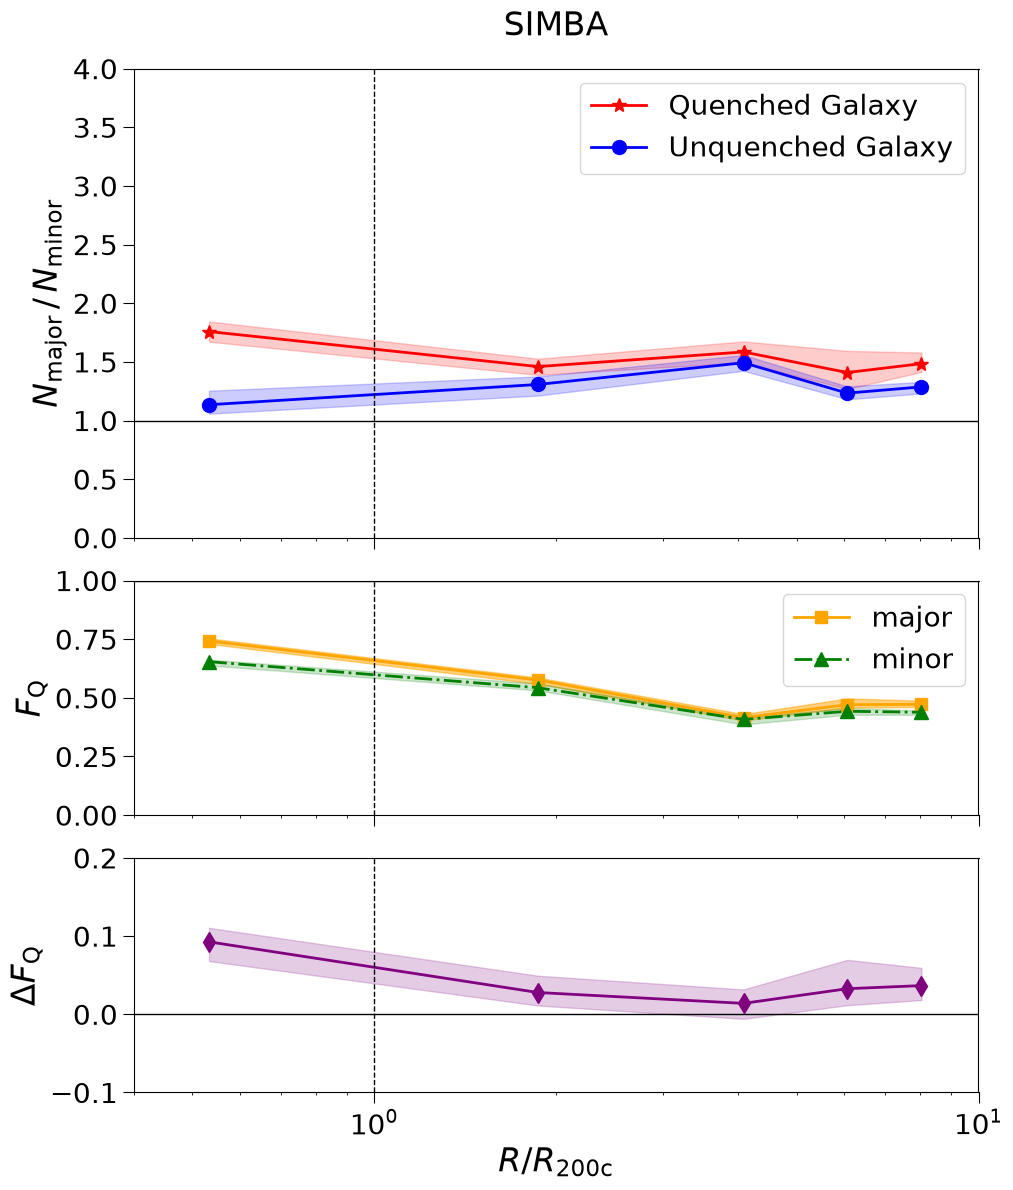

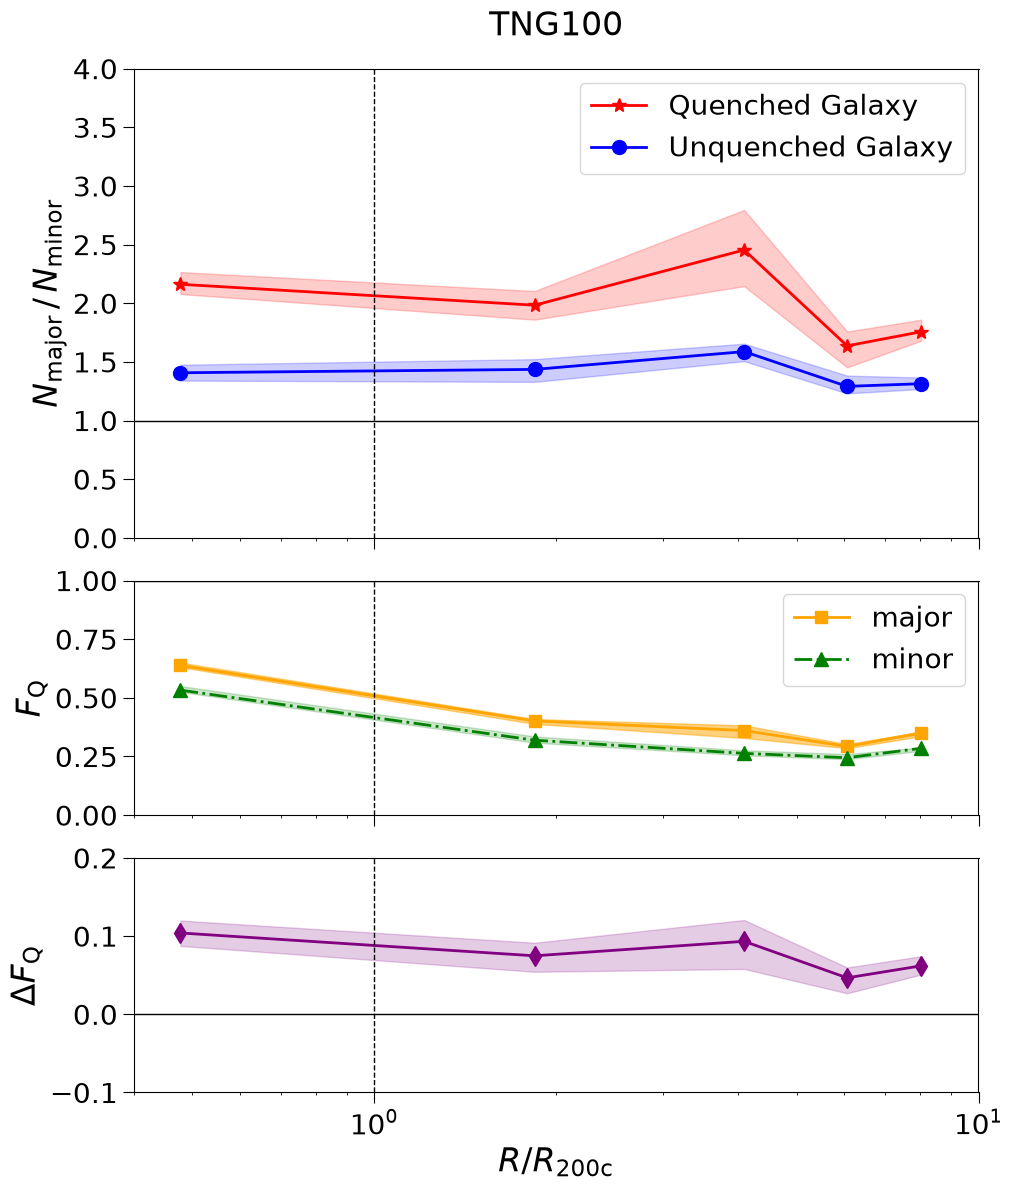

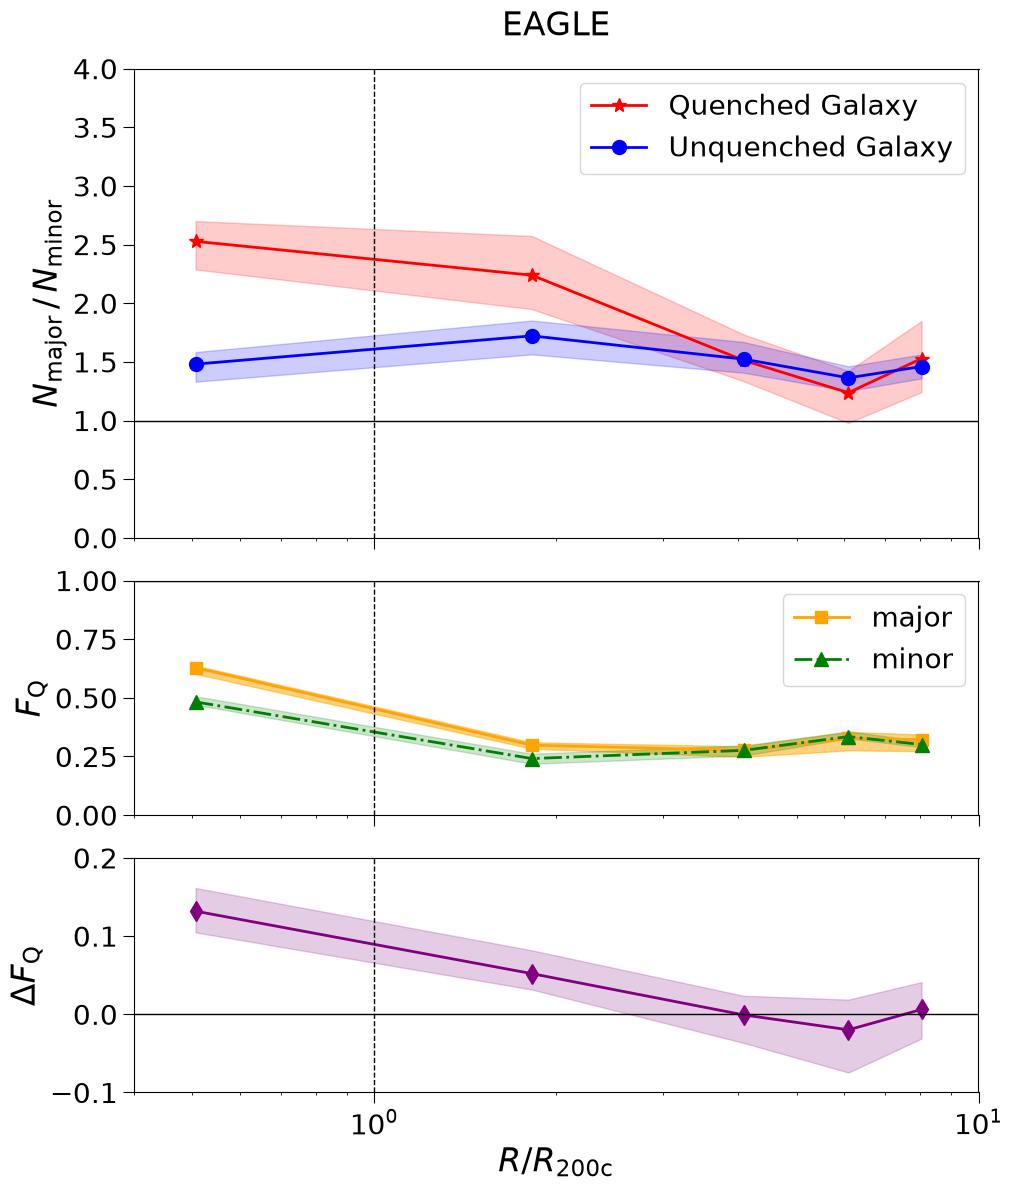

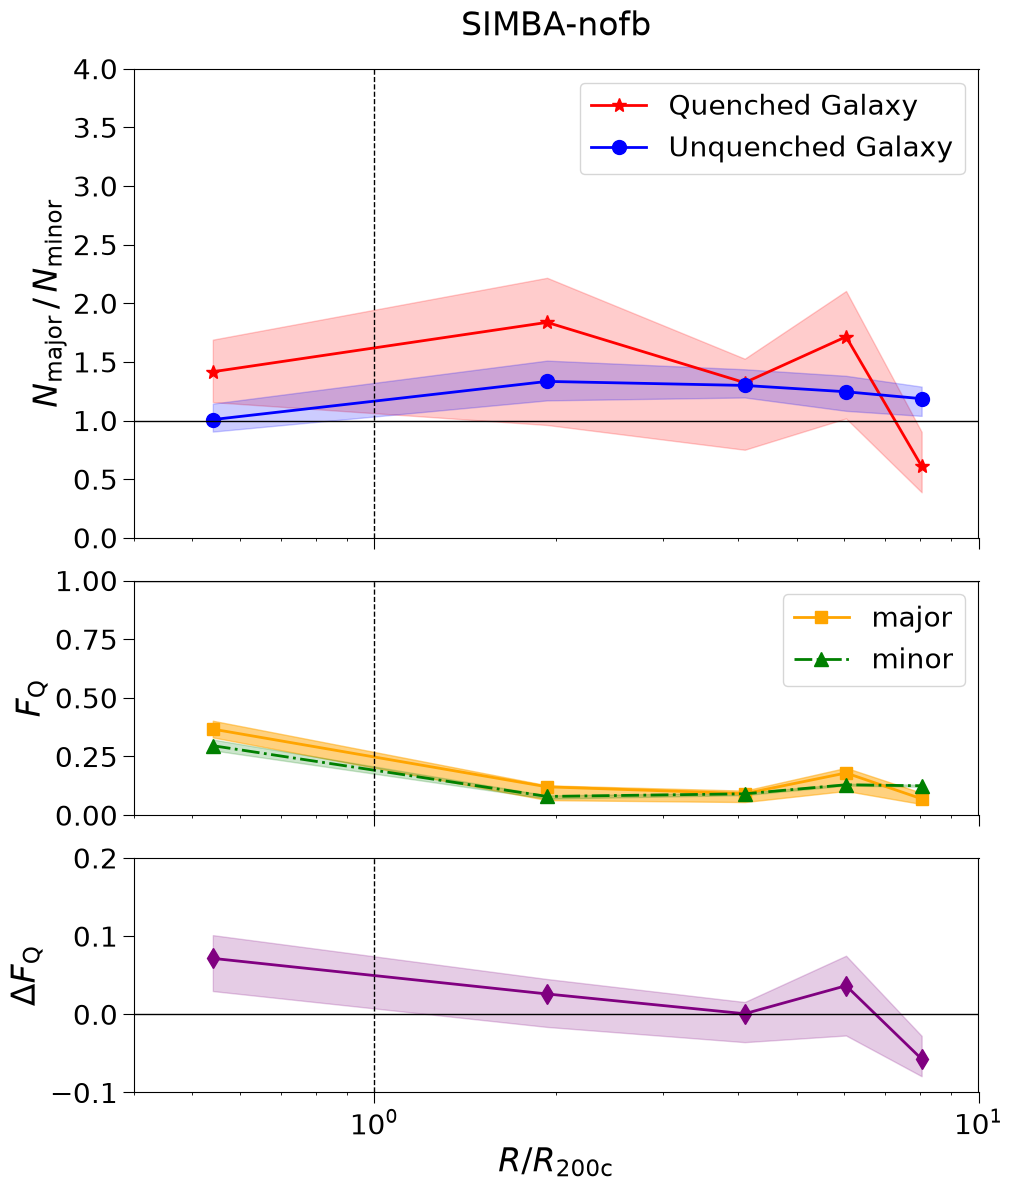

In [4]:
# ===================== 1. Simulation Configurations =====================
simulations_config = [
    {
        "name": "SIMBA",
        "title": "SIMBA",
        "snapnum_center": "151",
        "redshift": "0.0",
        "save_prefix": "SIMBA",
    },
    {
        "name": "TNG100",
        "title": "TNG100", 
        "snapnum_center": "099",
        "redshift": "0.0",
        "save_prefix": "TNG100",
    },
    {
        "name": "EAGLE",
        "title": "EAGLE",
        "snapnum_center": "028_z000p000",
        "redshift": "0.0",
        "save_prefix": "EAGLE",
    },
    {
        "name": "SIMBAnofb",
        "title": "SIMBA-nofb",
        "snapnum_center": "151",
        "redshift": "0.0",
        "save_prefix": "SIMBAnofb",
    },
]

# General parameters
quantity = "R"
quantity_type = "RR200cRatio_mean.npy"
x_name = r"$R/R_\mathrm{200c}$"
xmin = 0.04
xmax = 7
N_load = 50
ITM = False

# ===================== 2. Processing Loop Across Simulations =====================
for sim_cfg in simulations_config:
    sim_name = sim_cfg["name"]
    title = sim_cfg["title"]
    snapnum = sim_cfg["snapnum_center"]
    redshift = sim_cfg["redshift"]
    save_prefix = sim_cfg["save_prefix"]

    base_path0 = f"fig_data_R/{sim_name}/"

    part_type_list = ["star_axis"]
    axis_state = ["all"]

    R = [[[], []], [[], []]]
    N_ratio = [[[], []], [[], []]]
    QN_ratio = [[[], []], [[], []]]
    notQN_ratio = [[[], []], [[], []]]
    Qfrac_major = [[[], []], [[], []]]
    Qfrac_minor = [[[], []], [[], []]]
    delta_Qfrac = [[[], []], [[], []]]

    for i in range(len(part_type_list)):
        for j in range(len(axis_state)):
            base_path = (
                base_path0
                + part_type_list[i]
                + "/"
                + str(snapnum)
                + "/"
                + axis_state[j]
                + "/"
            )
            R[i][j] = np.load(base_path + quantity_type)

            for N_i in range(N_load + 1):
                if N_i == 0:
                    suffix = "ave/"
                else:
                    suffix = f"{N_i-1}/"

                N_ratio[i][j].append(
                    np.load(base_path + suffix + "N_ratio.npy")
                )
                QN_ratio[i][j].append(
                    np.load(base_path + suffix + "QN_ratio.npy")
                )
                notQN_ratio[i][j].append(
                    np.load(base_path + suffix + "notQN_ratio.npy")
                )

                Qfrac_major_i_j_k = np.load(
                    base_path + suffix + "Qfrac_major.npy"
                )
                Qfrac_minor_i_j_k = np.load(
                    base_path + suffix + "Qfrac_minor.npy"
                )

                Qfrac_major[i][j].append(Qfrac_major_i_j_k)
                Qfrac_minor[i][j].append(Qfrac_minor_i_j_k)
                delta_Qfrac[i][j].append(
                    Qfrac_major_i_j_k - Qfrac_minor_i_j_k
                )

            N_ratio[i][j] = np.vstack(N_ratio[i][j])
            Qfrac_major[i][j] = np.vstack(Qfrac_major[i][j])
            Qfrac_minor[i][j] = np.vstack(Qfrac_minor[i][j])
            delta_Qfrac[i][j] = np.vstack(delta_Qfrac[i][j])

    # Compute statistical uncertainties and means
    (
        N_ratio_ave,
        N_ratio_mean,
        N_ratio_sigma,
        N_ratio_683,
        N_ratio_997,
    ) = Plot_Process(N_ratio)
    (
        QN_ratio_ave,
        QN_ratio_mean,
        QN_ratio_sigma,
        QN_ratio_683,
        QN_ratio_997,
    ) = Plot_Process(QN_ratio)
    (
        notQN_ratio_ave,
        notQN_ratio_mean,
        notQN_ratio_sigma,
        notQN_ratio_683,
        notQN_ratio_997,
    ) = Plot_Process(notQN_ratio)
    (
        Qfrac_major_ave,
        Qfrac_major_mean,
        Qfrac_major_sigma,
        Qfrac_major_683,
        Qfrac_major_997,
    ) = Plot_Process(Qfrac_major)
    (
        Qfrac_minor_ave,
        Qfrac_minor_mean,
        Qfrac_minor_sigma,
        Qfrac_minor_683,
        Qfrac_minor_997,
    ) = Plot_Process(Qfrac_minor)
    (
        delta_Qfrac_ave,
        delta_Qfrac_mean,
        delta_Qfrac_sigma,
        delta_Qfrac_683,
        delta_Qfrac_997,
    ) = Plot_Process(delta_Qfrac)

    # ===================== Core: 3 Subplots Combined with Shared X-axis =====================
    # 3 rows, 1 column layout with shared X-axis and custom height ratios (2:1:1)
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(10, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1, 1]},
    )

    # Assign axes for clarity
    ax1 = axes[0]  # Subplot 1: Spatial Anisotropy (N_major / N_minor)
    ax2 = axes[1]  # Subplot 2: Quenched Fractions (FQ)
    ax3 = axes[2]  # Subplot 3: Quenched Fraction Excess (ΔFQ)

    # ===================== Unified Font Parameters =====================
    label_font = 24
    tick_font = 20
    legend_font = 20

    # ===================== Subplot 1: N_major / N_minor =====================
    ax1.plot(
        R[0][0],
        QN_ratio_mean[0][0],
        color="red",
        linestyle="-",
        lw=2,
        marker="*",
        ms=10,
        label="Quenched Galaxy",
    )
    ax1.fill_between(
        R[0][0],
        QN_ratio_997[0][0][0],
        QN_ratio_997[0][0][1],
        color="red",
        alpha=0.2,
    )

    ax1.plot(
        R[0][0],
        notQN_ratio_mean[0][0],
        color="blue",
        linestyle="-",
        lw=2,
        marker="o",
        ms=10,
        label="Unquenched Galaxy",
    )
    ax1.fill_between(
        R[0][0],
        notQN_ratio_997[0][0][0],
        notQN_ratio_997[0][0][1],
        color="blue",
        alpha=0.2,
    )

    # Axis limits and styles
    ax1.set_xlim(0.4, 10)
    ax1.set_ylim(0, 4)

    ax1.axhline(1, c="k", lw=1)
    ax1.axvline(1, c="k", ls="--", lw=1)
    ax1.set_ylabel(
        r"$N_\mathrm{major}\,/\,N_\mathrm{minor}$", fontsize=label_font
    )
    ax1.legend(loc="upper right", fontsize=legend_font)
    ax1.set_title(f"{title}", fontsize=24, pad=24)
    ax1.tick_params(axis="both", which="major", labelsize=tick_font, length=8)

    # ===================== Subplot 2: F_Q major vs. minor =====================
    ax2.plot(
        R[0][0],
        Qfrac_major_ave[0][0],
        color="orange",
        lw=2,
        marker="s",
        ms=8,
        label="major",
    )
    ax2.fill_between(
        R[0][0],
        Qfrac_major_997[0][0][0],
        Qfrac_major_997[0][0][1],
        color="orange",
        alpha=0.5,
    )
    ax2.plot(
        R[0][0],
        Qfrac_minor_ave[0][0],
        color="green",
        lw=2,
        ls="-.",
        marker="^",
        ms=10,
        label="minor",
    )
    ax2.fill_between(
        R[0][0],
        Qfrac_minor_997[0][0][0],
        Qfrac_minor_997[0][0][1],
        color="green",
        alpha=0.2,
    )

    ax2.set_ylim(0, 1)

    ax2.axhline(1, c="k", lw=1)
    ax2.axvline(1, c="k", ls="--", lw=1)
    ax2.set_ylabel(r"$F_\mathrm{Q}$", fontsize=label_font)
    ax2.legend(loc="upper right", fontsize=legend_font)
    ax2.tick_params(axis="both", which="major", labelsize=tick_font, length=8)

    # ===================== Subplot 3: ΔF_Q =====================
    ax3.plot(
        R[0][0],
        delta_Qfrac_mean[0][0],
        color="purple",
        lw=2,
        marker="d",
        ms=10,
    )
    ax3.fill_between(
        R[0][0],
        delta_Qfrac_997[0][0][0],
        delta_Qfrac_997[0][0][1],
        color="purple",
        alpha=0.2,
    )

    ax3.set_ylim(-0.1, 0.2)

    ax3.axhline(0, c="k", lw=1)
    ax3.axvline(1, c="k", ls="--", lw=1)
    ax3.set_xlabel(x_name, fontsize=label_font)
    ax3.set_ylabel(r"$\Delta F_\mathrm{Q}$", fontsize=label_font)
    ax3.tick_params(axis="both", which="major", labelsize=tick_font, length=8)

    # ===================== Global Figure Settings =====================
    ax3.set_xscale("log")
    plt.tight_layout()

    # Create directory if it does not exist and save figure
    out_fig_dir = "fig_result"
    os.makedirs(out_fig_dir, exist_ok=True)
    save_path = f"{out_fig_dir}/{save_prefix}_QF_{quantity}_BCG_z_0.pdf"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()